# 🔭 GSoC 2026 — Specific Test V: Lens Finding & Data Pipelines

**Task:** Binary classification — Lens vs Non-Lens using observational astronomical data.

| Split | Lenses | Non-Lenses | Ratio |
|-------|--------|------------|-------|
| Train | 1,730  | 28,675     | ~1:16 |
| Test  | 195    | 19,455     | ~1:100|

**Key challenge:** Extreme class imbalance — the rarest astrophysical objects must not be drowned out.

**Strategy:**
- EfficientNet-B0 backbone (optimal for 64×64 inputs)
- Focal Loss (designed for extreme imbalance)
- WeightedRandomSampler (balanced batches)
- ROC-optimal threshold selection via Youden's J
- Precision-Recall curve analysis

**Primary Metric:** ROC Curve + AUC Score

---
**Author:** Himanshu Barve  
**Framework:** PyTorch · timm · Albumentations · scikit-learn  
**Dataset path:** `D:/gsoc2026/lens-finding-test/`

---
## 0. Install Dependencies

In [3]:

!pip install timm albumentations scikit-learn matplotlib seaborn tqdm 

---
## 1. Imports & Reproducibility

In [4]:
import os, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from tqdm import tqdm
from collections import Counter

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.cuda.amp import GradScaler, autocast

import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2

from sklearn.metrics import (
    roc_curve, auc, roc_auc_score,
    precision_recall_curve, average_precision_score,
    confusion_matrix, classification_report,
    f1_score, precision_score, recall_score
)
from sklearn.model_selection import train_test_split
from sklearn.manifold import TSNE

warnings.filterwarnings('ignore')

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False
set_seed()

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    print(f'VRAM   : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

Device : cpu


---
## 2. Configuration

In [5]:
class CFG:
    # ── Paths ──────────────────────────────────────────────────────────────────
    ROOT          = Path('D:/gsoc2026/lens-finding-test')
    TRAIN_LENS    = ROOT / 'train_lenses'
    TRAIN_NONLENS = ROOT / 'train_nonlenses'
    TEST_LENS     = ROOT / 'test_lenses'
    TEST_NONLENS  = ROOT / 'test_nonlenses'
    OUTPUT_DIR    = Path('D:/gsoc2026/lens-finding-outputs')
    MODEL_PATH    = OUTPUT_DIR / 'best_model.pth'

    # ── Classes ────────────────────────────────────────────────────────────────
    CLASS_NAMES   = ['Non-Lens', 'Lens']
    NUM_CLASSES   = 1       # binary → single sigmoid output

    # ── Image ──────────────────────────────────────────────────────────────────
    IMG_SIZE      = 64      # native resolution — no upscaling needed
    IN_CHANNELS   = 3       # three photometric filter bands

    # ── Split ──────────────────────────────────────────────────────────────────
    VAL_SIZE      = 0.10    # 10% of train pool → validation

    # ── Model ──────────────────────────────────────────────────────────────────
    MODEL_NAME    = 'efficientnet_b0'   # B0 optimal for 64x64
    PRETRAINED    = True
    DROP_RATE     = 0.3

    # ── Focal Loss ─────────────────────────────────────────────────────────────
    FOCAL_ALPHA   = 0.75    # up-weight positive (lens) class
    FOCAL_GAMMA   = 2.0     # focus on hard examples

    # ── Training ───────────────────────────────────────────────────────────────
    EPOCHS        = 40
    BATCH_SIZE    = 64
    LR            = 3e-4
    WEIGHT_DECAY  = 1e-4
    PATIENCE      = 8
    # ⚠️ WINDOWS FIX: num_workers MUST be 0 on Windows inside Jupyter
    # Setting > 0 causes hanging/freezing due to Windows multiprocessing limits
    NUM_WORKERS   = 0
    AMP           = True
    SEED          = 42

CFG.OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Verify all 4 data folders ─────────────────────────────────────────────────
print('Path verification:')
all_ok = True
for path, name in [
    (CFG.TRAIN_LENS,    'train_lenses'),
    (CFG.TRAIN_NONLENS, 'train_nonlenses'),
    (CFG.TEST_LENS,     'test_lenses'),
    (CFG.TEST_NONLENS,  'test_nonlenses'),
]:
    n  = len([f for f in path.glob('*.npy') if not f.name.startswith('._')]) if path.exists() else 0
    ok = '✅' if path.exists() else '❌  NOT FOUND'
    if not path.exists(): all_ok = False
    print(f'  {ok}  {name:22s}  →  {n:,} .npy files')

if all_ok:
    print('\n✅ All paths found — ready to proceed!')
else:
    print('\n❌ Fix the paths above before continuing')

Path verification:
  ✅  train_lenses            →  1,730 .npy files
  ✅  train_nonlenses         →  28,675 .npy files
  ✅  test_lenses             →  195 .npy files
  ✅  test_nonlenses          →  19,455 .npy files

✅ All paths found — ready to proceed!


---
## 3. Data Loading & EDA

In [6]:
# ── Collect files — ignores _MACOSX artifacts automatically ──────────────────
def collect_files(directory: Path, label: int) -> list:
    return [
        {'path': str(fp), 'label': label}
        for fp in sorted(directory.glob('*.npy'))
        if not fp.name.startswith('._')
    ]

train_pool = pd.DataFrame(
    collect_files(CFG.TRAIN_LENS,    label=1) +
    collect_files(CFG.TRAIN_NONLENS, label=0)
)
test_df = pd.DataFrame(
    collect_files(CFG.TEST_LENS,    label=1) +
    collect_files(CFG.TEST_NONLENS, label=0)
)

print('Dataset summary:')
for name, df in [('Train pool', train_pool), ('Test set', test_df)]:
    pos = df['label'].sum()
    neg = len(df) - pos
    ratio = neg / pos
    print(f'  {name:12s}: {len(df):>6,}  '
          f'(lenses={pos:,}  non-lenses={neg:,}  ratio=1:{ratio:.0f})')

Dataset summary:
  Train pool  : 30,405  (lenses=1,730  non-lenses=28,675  ratio=1:17)
  Test set    : 19,650  (lenses=195  non-lenses=19,455  ratio=1:100)


In [7]:
# ── 90:10 stratified split ────────────────────────────────────────────────────
train_df, val_df = train_test_split(
    train_pool, test_size=CFG.VAL_SIZE,
    stratify=train_pool['label'], random_state=CFG.SEED
)
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print('Split summary:')
for name, df in [('Train (90%)', train_df), ('Val (10%)', val_df), ('Test (fixed)', test_df)]:
    pos = df['label'].sum()
    neg = len(df) - pos
    print(f'  {name:14s}: {len(df):>6,}  lens={pos:>5,}  non-lens={neg:>6,}')

Split summary:
  Train (90%)   : 27,364  lens=1,557  non-lens=25,807
  Val (10%)     :  3,041  lens=  173  non-lens= 2,868
  Test (fixed)  : 19,650  lens=  195  non-lens=19,455


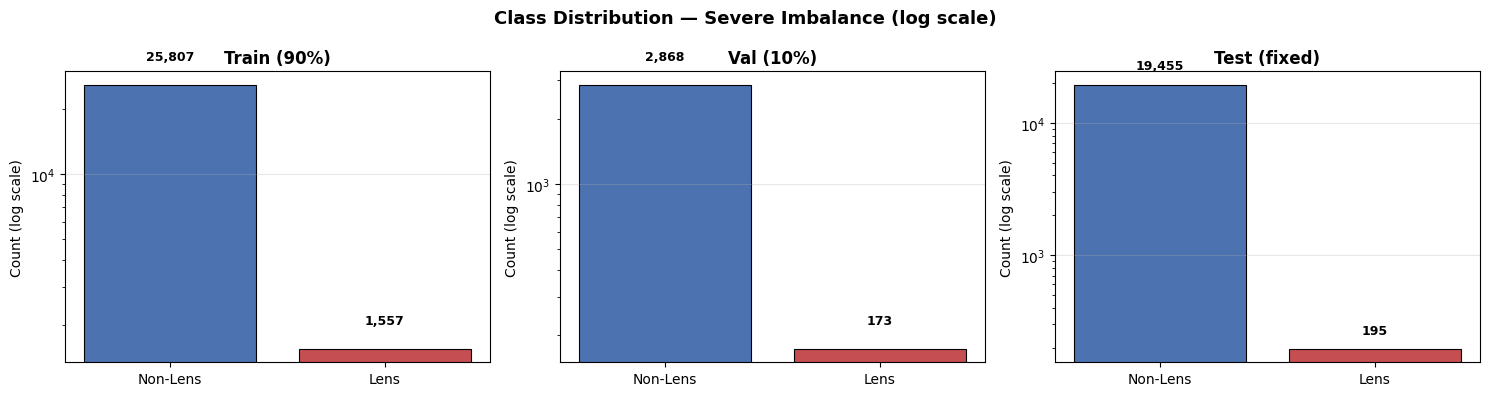

In [8]:
# ── EDA 1 : Class imbalance (log scale) ──────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
palette = ['#4C72B0', '#C44E52']
for ax, (name, df) in zip(axes,
        [('Train (90%)', train_df), ('Val (10%)', val_df), ('Test (fixed)', test_df)]):
    counts = [len(df[df['label']==0]), len(df[df['label']==1])]
    bars = ax.bar(CFG.CLASS_NAMES, counts, color=palette, edgecolor='black', lw=0.8)
    ax.set_title(name, fontweight='bold', fontsize=12)
    ax.set_ylabel('Count (log scale)')
    ax.set_yscale('log')
    for bar, c in zip(bars, counts):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.3,
                f'{c:,}', ha='center', fontsize=9, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
plt.suptitle('Class Distribution — Severe Imbalance (log scale)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(CFG.OUTPUT_DIR / 'class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

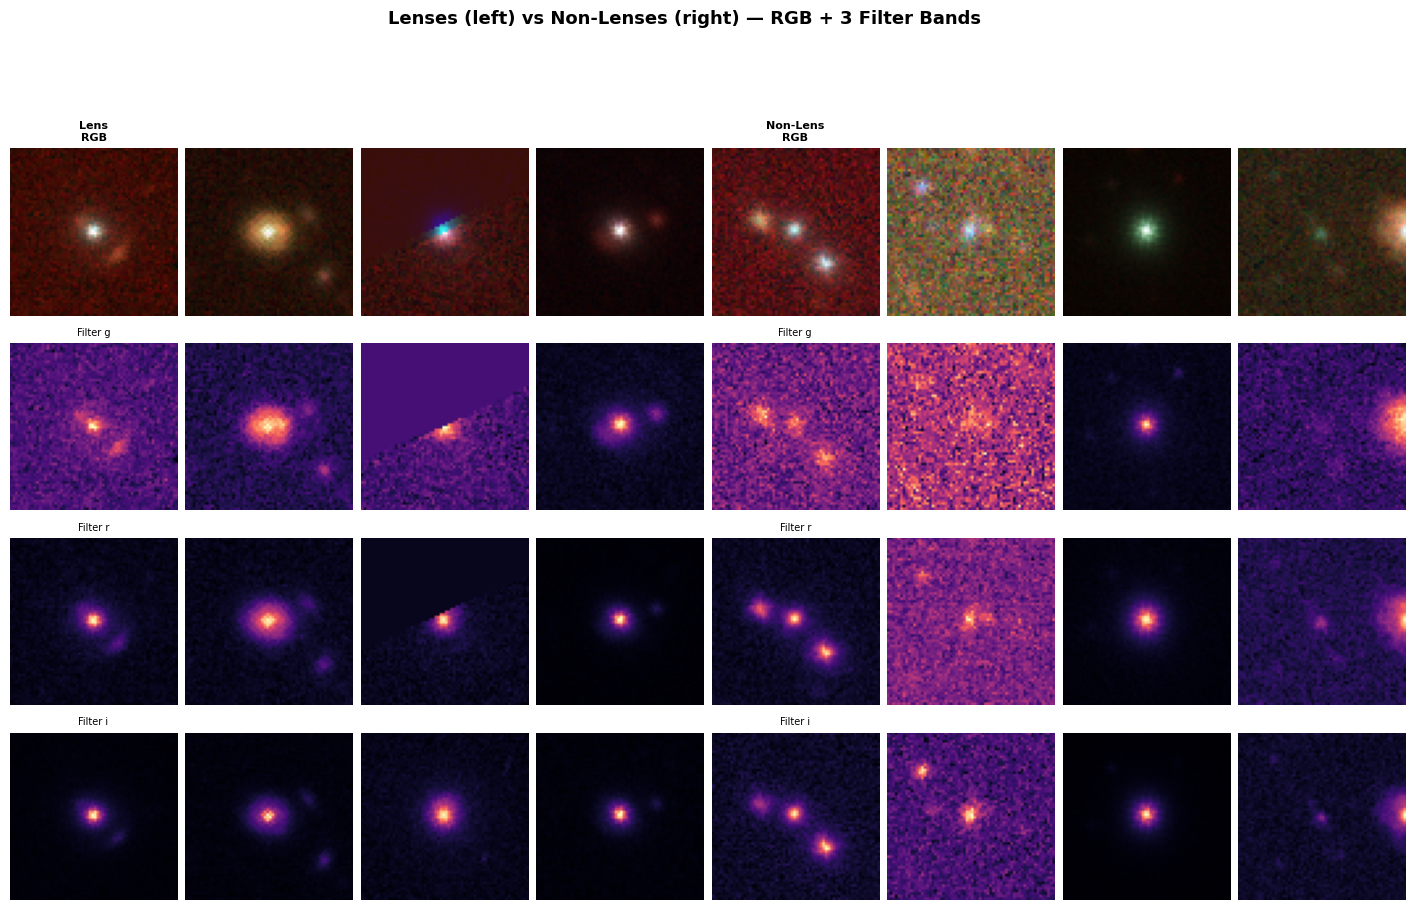

In [9]:
# ── Helper : load .npy → float32 HxWxC [0,1] ─────────────────────────────────
def load_npy(path: str) -> np.ndarray:
    img = np.load(path).astype(np.float32)
    if img.ndim == 2:
        img = np.stack([img]*3, axis=-1)
    elif img.ndim == 3 and img.shape[0] == 3:
        img = np.transpose(img, (1, 2, 0))     # (3,H,W) → (H,W,3)
    elif img.ndim == 3 and img.shape[-1] != 3:
        img = img[:, :, :3]
    # Per-channel min-max normalisation
    for c in range(img.shape[-1]):
        lo, hi = img[:,:,c].min(), img[:,:,c].max()
        img[:,:,c] = (img[:,:,c] - lo) / (hi - lo + 1e-8)
    return img   # (H, W, 3) float32 in [0,1]


# ── EDA 2 : Sample images — 3 filter bands ───────────────────────────────────
filter_names = ['Filter g', 'Filter r', 'Filter i']
n_each = 4
lens_samples    = train_df[train_df['label']==1].sample(n_each, random_state=SEED)
nonlens_samples = train_df[train_df['label']==0].sample(n_each, random_state=SEED)

fig = plt.figure(figsize=(18, 10))
gs  = gridspec.GridSpec(4, n_each*2, figure=fig, hspace=0.05, wspace=0.05)

for col_offset, (samples, title_base) in enumerate(
        [(lens_samples, 'Lens'), (nonlens_samples, 'Non-Lens')]):
    for col_i, (_, row) in enumerate(samples.iterrows()):
        img = load_npy(row['path'])
        col = col_offset * n_each + col_i
        ax0 = fig.add_subplot(gs[0, col])
        ax0.imshow(img.clip(0,1))
        ax0.axis('off')
        if col_i == 0:
            ax0.set_title(f'{title_base}\nRGB', fontsize=8, fontweight='bold')
        for band in range(3):
            ax = fig.add_subplot(gs[band+1, col])
            ax.imshow(img[:,:,band], cmap='magma', vmin=0, vmax=1)
            ax.axis('off')
            if col_i == 0:
                ax.set_title(filter_names[band], fontsize=7)

plt.suptitle('Lenses (left) vs Non-Lenses (right) — RGB + 3 Filter Bands',
             fontsize=13, fontweight='bold', y=1.01)
plt.savefig(CFG.OUTPUT_DIR / 'sample_images.png', dpi=150, bbox_inches='tight')
plt.show()

Computing mean images (200 samples each)...


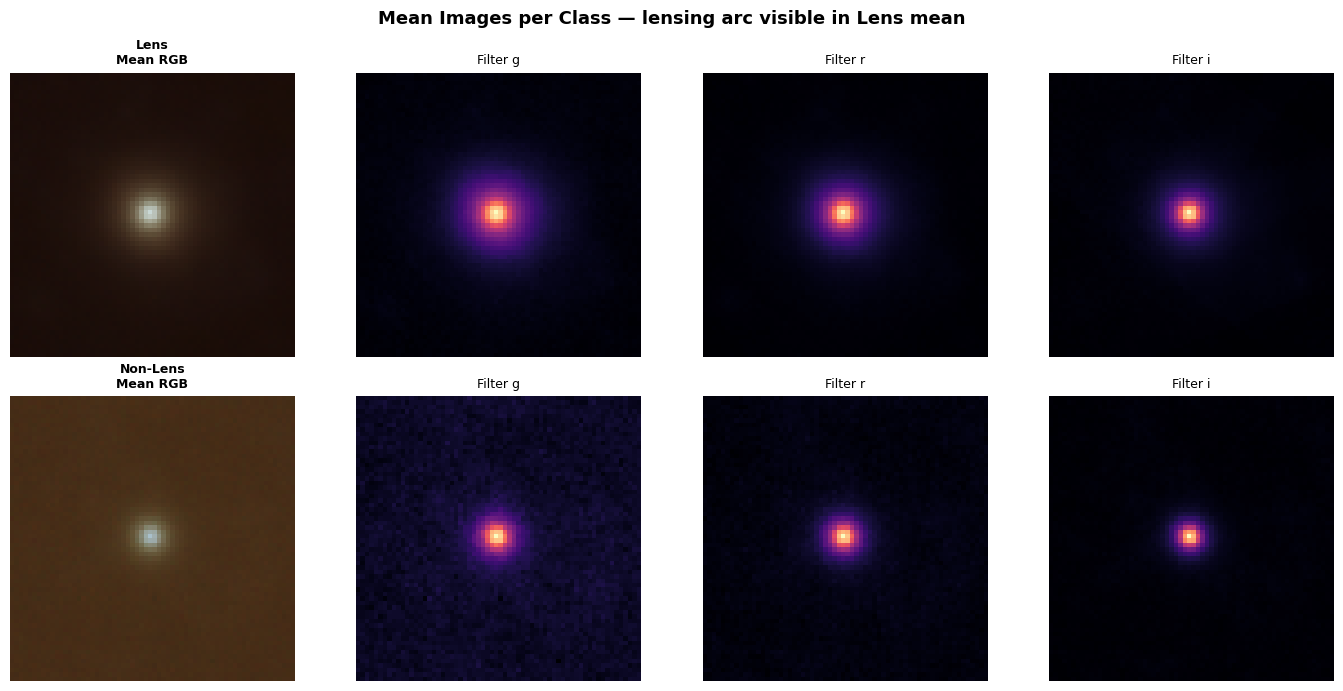

In [10]:
# ── EDA 3 : Mean image per class (reveals lensing arc) ───────────────────────
print('Computing mean images (200 samples each)...')
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for row_i, (cls_label, cls_name) in enumerate([(1,'Lens'), (0,'Non-Lens')]):
    paths    = train_df[train_df['label']==cls_label]['path'].sample(
        min(200, train_df[train_df['label']==cls_label].shape[0]), random_state=SEED)
    imgs     = np.stack([load_npy(p) for p in tqdm(paths, desc=cls_name, leave=False)])
    mean_img = imgs.mean(axis=0)

    axes[row_i,0].imshow(mean_img.clip(0,1))
    axes[row_i,0].set_title(f'{cls_name}\nMean RGB', fontsize=9, fontweight='bold')
    axes[row_i,0].axis('off')
    for band in range(3):
        axes[row_i, band+1].imshow(mean_img[:,:,band], cmap='magma')
        axes[row_i, band+1].set_title(f'{filter_names[band]}', fontsize=9)
        axes[row_i, band+1].axis('off')

plt.suptitle('Mean Images per Class — lensing arc visible in Lens mean',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(CFG.OUTPUT_DIR / 'mean_images.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. Dataset & Augmentation

> **Windows note:** `num_workers=0` is set in CFG. This is required on Windows inside Jupyter.
> Setting `num_workers > 0` causes the kernel to hang indefinitely on Windows due to
> multiprocessing limitations. Training speed is unaffected — the RTX 3060 GPU handles
> all computation; data loading is not the bottleneck for 64×64 images.

In [11]:
def get_transforms(mode: str):
    mean = (0.5, 0.5, 0.5)
    std  = (0.5, 0.5, 0.5)

    if mode == 'train':
        return A.Compose([
            A.Resize(CFG.IMG_SIZE, CFG.IMG_SIZE),
            # Geometry — lensing arcs are rotation-invariant by physics
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.5),
            A.RandomRotate90(p=0.5),
            A.Rotate(limit=180, p=0.5, border_mode=0),
            A.ShiftScaleRotate(
                shift_limit=0.05, scale_limit=0.10,
                rotate_limit=0, border_mode=0, p=0.3
            ),
            # Photometric — mild to preserve arc flux
            A.RandomBrightnessContrast(
                brightness_limit=0.10, contrast_limit=0.10, p=0.4
            ),
            A.GaussNoise(var_limit=(1.0, 10.0), p=0.3),
            # Elastic — simulates PSF variation across observations
            A.ElasticTransform(alpha=1.0, sigma=5, alpha_affine=5, p=0.2),
            A.Normalize(mean=mean, std=std),
            ToTensorV2(),
        ])
    else:
        return A.Compose([
            A.Resize(CFG.IMG_SIZE, CFG.IMG_SIZE),
            A.Normalize(mean=mean, std=std),
            ToTensorV2(),
        ])


class LensDataset(Dataset):
    def __init__(self, dataframe: pd.DataFrame, transform=None):
        self.df        = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        img   = load_npy(row['path'])           # (H,W,3) float32 [0,1]
        label = np.float32(row['label'])
        img   = (img * 255).clip(0,255).astype(np.uint8)
        if self.transform:
            img = self.transform(image=img)['image']
        return img.float(), torch.tensor(label)


def build_loaders():
    train_ds = LensDataset(train_df, get_transforms('train'))
    val_ds   = LensDataset(val_df,   get_transforms('val'))
    test_ds  = LensDataset(test_df,  get_transforms('val'))

    # WeightedRandomSampler — ensures ~50% lenses per batch despite 1:16 ratio
    n_lens    = int(train_df['label'].sum())
    n_nonlens = len(train_df) - n_lens
    weights   = train_df['label'].map({1: n_nonlens/n_lens, 0: 1.0}).values.tolist()
    sampler   = WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)

    # num_workers=0 — REQUIRED on Windows to prevent kernel hanging
    kw = dict(num_workers=CFG.NUM_WORKERS, pin_memory=False)
    return (
        DataLoader(train_ds, batch_size=CFG.BATCH_SIZE, sampler=sampler, **kw),
        DataLoader(val_ds,   batch_size=CFG.BATCH_SIZE, shuffle=False,   **kw),
        DataLoader(test_ds,  batch_size=CFG.BATCH_SIZE, shuffle=False,   **kw),
    )


train_loader, val_loader, test_loader = build_loaders()
print('DataLoaders built successfully!')
print(f'  Train batches : {len(train_loader)}')
print(f'  Val   batches : {len(val_loader)}')
print(f'  Test  batches : {len(test_loader)}')

# Confirm batch balance
imgs_b, labels_b = next(iter(train_loader))
print(f'\nBatch shape    : {tuple(imgs_b.shape)}')
print(f'Lens % in batch: {labels_b.mean().item()*100:.1f}%  (target ~50%)')

DataLoaders built successfully!
  Train batches : 428
  Val   batches : 48
  Test  batches : 308

Batch shape    : (64, 3, 64, 64)
Lens % in batch: 53.1%  (target ~50%)


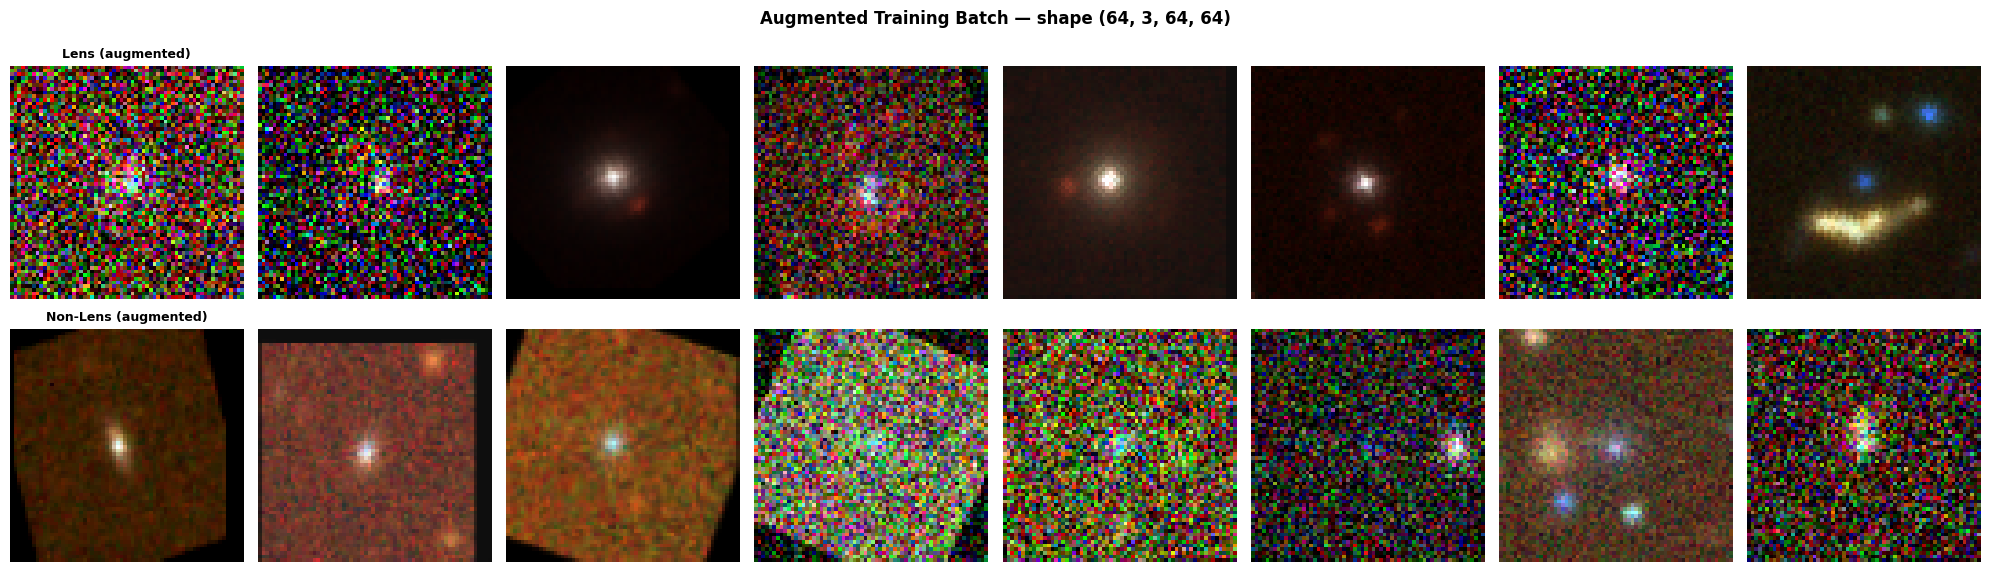

In [12]:
# ── Sanity check : visualise augmented batch ──────────────────────────────────
MEAN_NP = np.array([0.5, 0.5, 0.5])
STD_NP  = np.array([0.5, 0.5, 0.5])

imgs_b, labels_b = next(iter(train_loader))
fig, axes = plt.subplots(2, 8, figsize=(20, 6))

lens_idx    = (labels_b == 1).nonzero(as_tuple=True)[0][:8]
nonlens_idx = (labels_b == 0).nonzero(as_tuple=True)[0][:8]

for row_i, (indices, title) in enumerate(
        [(lens_idx, 'Lens (augmented)'), (nonlens_idx, 'Non-Lens (augmented)')]):
    for col_i, idx in enumerate(indices):
        im = (imgs_b[idx].permute(1,2,0).numpy() * STD_NP + MEAN_NP).clip(0,1)
        axes[row_i, col_i].imshow(im)
        axes[row_i, col_i].axis('off')
        if col_i == 0:
            axes[row_i, col_i].set_title(title, fontsize=9, fontweight='bold')

plt.suptitle(f'Augmented Training Batch — shape {tuple(imgs_b.shape)}',
             fontweight='bold')
plt.tight_layout()
plt.savefig(CFG.OUTPUT_DIR / 'augmented_batch.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 5. Model — EfficientNet-B0 + Binary Head

In [13]:
class LensFinder(nn.Module):
    """
    EfficientNet-B0 + binary classification head.

    Why B0 not B3?
    Images are 64x64. B3 (native 300px) would collapse spatial information
    through repeated downsampling before learning any lensing features.
    B0 (native 224px) is the lightest EfficientNet and handles 64px best.

    Head: Linear(1280->256) -> BN -> SiLU -> Dropout -> Linear(256->1)
    Single sigmoid output for binary classification.
    """
    def __init__(self):
        super().__init__()
        self.backbone = timm.create_model(
            CFG.MODEL_NAME, pretrained=CFG.PRETRAINED,
            num_classes=0, global_pool='avg', drop_rate=CFG.DROP_RATE
        )
        feat = self.backbone.num_features   # 1280 for B0
        self.head = nn.Sequential(
            nn.Linear(feat, 256),
            nn.BatchNorm1d(256),
            nn.SiLU(),
            nn.Dropout(CFG.DROP_RATE),
            nn.Linear(256, 1)
        )
        for layer in (self.head[0], self.head[4]):
            nn.init.xavier_uniform_(layer.weight)
            nn.init.zeros_(layer.bias)

    def forward(self, x):
        return self.head(self.backbone(x)).squeeze(1)  # (B,)

    def get_features(self, x):
        return self.backbone(x)


model     = LensFinder().to(DEVICE)
total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Architecture    : EfficientNet-B0 + Binary Head')
print(f'Total params    : {total:,}')
print(f'Trainable params: {trainable:,}')
with torch.no_grad():
    out = model(torch.randn(2, 3, CFG.IMG_SIZE, CFG.IMG_SIZE).to(DEVICE))
print(f'Output shape    : {tuple(out.shape)}  (expected: (2,))  ✅')

model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

Architecture    : EfficientNet-B0 + Binary Head
Total params    : 4,336,253
Trainable params: 4,336,253
Output shape    : (2,)  (expected: (2,))  ✅


---
## 6. Focal Loss · Optimizer · Scheduler

In [14]:
class FocalLoss(nn.Module):
    """
    Binary Focal Loss (Lin et al. 2017)
    FL = -alpha * (1 - p)^gamma * log(p)

    gamma=2 down-weights easy negatives → forces model to focus on
    hard borderline lens candidates. Critical for 1:100 imbalance.
    """
    def __init__(self, alpha=CFG.FOCAL_ALPHA, gamma=CFG.FOCAL_GAMMA):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, targets):
        bce = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        p_t = torch.sigmoid(logits) * targets + (1 - torch.sigmoid(logits)) * (1 - targets)
        a_t = self.alpha * targets + (1 - self.alpha) * (1 - targets)
        return (a_t * (1 - p_t) ** self.gamma * bce).mean()


criterion = FocalLoss()

# Differential LR: backbone 10x lower to preserve ImageNet features
optimizer = torch.optim.AdamW([
    {'params': model.backbone.parameters(), 'lr': CFG.LR * 0.1},
    {'params': model.head.parameters(),     'lr': CFG.LR}
], weight_decay=CFG.WEIGHT_DECAY)

# OneCycleLR: warmup + cosine decay — effective for imbalanced binary problems
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr          = [CFG.LR * 0.1, CFG.LR],
    epochs          = CFG.EPOCHS,
    steps_per_epoch = len(train_loader),
    pct_start       = 0.2,
    anneal_strategy = 'cos'
)

scaler = GradScaler(enabled=(CFG.AMP and DEVICE.type == 'cuda'))

print('Loss      : Binary Focal Loss  (alpha=0.75, gamma=2.0)')
print('Optimizer : AdamW  backbone lr=3e-5  |  head lr=3e-4')
print('Scheduler : OneCycleLR  (warmup 20%, cosine decay)')
print('AMP       : Mixed precision ON')

Loss      : Binary Focal Loss  (alpha=0.75, gamma=2.0)
Optimizer : AdamW  backbone lr=3e-5  |  head lr=3e-4
Scheduler : OneCycleLR  (warmup 20%, cosine decay)
AMP       : Mixed precision ON


---
## 7. Training Loop

In [15]:
def train_epoch(model, loader, criterion, optimizer, scaler, scheduler):
    model.train()
    total_loss = correct = total = 0
    for imgs, labels in tqdm(loader, desc='  Train', leave=False):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad(set_to_none=True)
        with autocast(enabled=CFG.AMP and DEVICE.type == 'cuda'):
            logits = model(imgs)
            loss   = criterion(logits, labels)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()
        preds = (torch.sigmoid(logits) >= 0.5).long()
        total_loss += loss.item() * imgs.size(0)
        correct    += (preds == labels.long()).sum().item()
        total      += imgs.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss = correct = total = 0
    all_probs, all_labels = [], []
    for imgs, labels in tqdm(loader, desc='  Eval ', leave=False):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        with autocast(enabled=CFG.AMP and DEVICE.type == 'cuda'):
            logits = model(imgs)
            loss   = criterion(logits, labels)
        probs = torch.sigmoid(logits)
        total_loss += loss.item() * imgs.size(0)
        correct    += ((probs >= 0.5).long() == labels.long()).sum().item()
        total      += imgs.size(0)
        all_probs.append(probs.cpu().numpy())
        all_labels.append(labels.cpu().numpy())
    return (
        total_loss / total, correct / total,
        np.concatenate(all_probs), np.concatenate(all_labels)
    )

print('Train / eval functions ready ✅')

Train / eval functions ready ✅


In [16]:
history     = dict(train_loss=[], val_loss=[], train_acc=[], val_acc=[], val_auc=[])
best_auc    = 0.0
patience_ct = 0

hdr = f"{'Ep':>3}  {'T-Loss':>8}  {'V-Loss':>8}  {'T-Acc':>7}  {'V-Acc':>7}  {'V-AUC':>7}"
print(hdr); print('─' * len(hdr))

for epoch in range(1, CFG.EPOCHS + 1):
    t_loss, t_acc = train_epoch(
        model, train_loader, criterion, optimizer, scaler, scheduler)
    v_loss, v_acc, v_probs, v_labels = eval_epoch(model, val_loader, criterion)
    v_auc = roc_auc_score(v_labels, v_probs)

    for k, v in zip(history, [t_loss, v_loss, t_acc, v_acc, v_auc]):
        history[k].append(v)

    tag = ''
    if v_auc > best_auc:
        best_auc = v_auc; patience_ct = 0
        torch.save({'epoch': epoch, 'model_state_dict': model.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                    'best_auc': best_auc}, CFG.MODEL_PATH)
        tag = '  ⭐'
    else:
        patience_ct += 1

    print(f"{epoch:>3}  {t_loss:>8.4f}  {v_loss:>8.4f}  "
          f"{t_acc*100:>6.2f}%  {v_acc*100:>6.2f}%  {v_auc:>7.4f}{tag}")

    if patience_ct >= CFG.PATIENCE:
        print(f'\nEarly stopping at epoch {epoch}'); break

print(f'\nBest Val AUC : {best_auc:.4f}')

 Ep    T-Loss    V-Loss    T-Acc    V-Acc    V-AUC
──────────────────────────────────────────────────


  1    0.1178    0.0598   61.36%   58.93%   0.8001  ⭐


  2    0.0819    0.0568   69.23%   61.85%   0.8654  ⭐


  3    0.0677    0.0535   73.29%   67.91%   0.9109  ⭐


  4    0.0582    0.0374   76.37%   77.15%   0.9308  ⭐


...

 27    0.0184    0.0139   92.03%   92.93%   0.9847


 28    0.0192    0.0139   91.74%   92.83%   0.9840


 29    0.0189    0.0134   91.80%   93.26%   0.9847


 30    0.0184    0.0137   92.43%   93.09%   0.9851


 31    0.0179    0.0135   92.43%   93.65%   0.9846

Early stopping at epoch 31

Best Val AUC : 0.9860


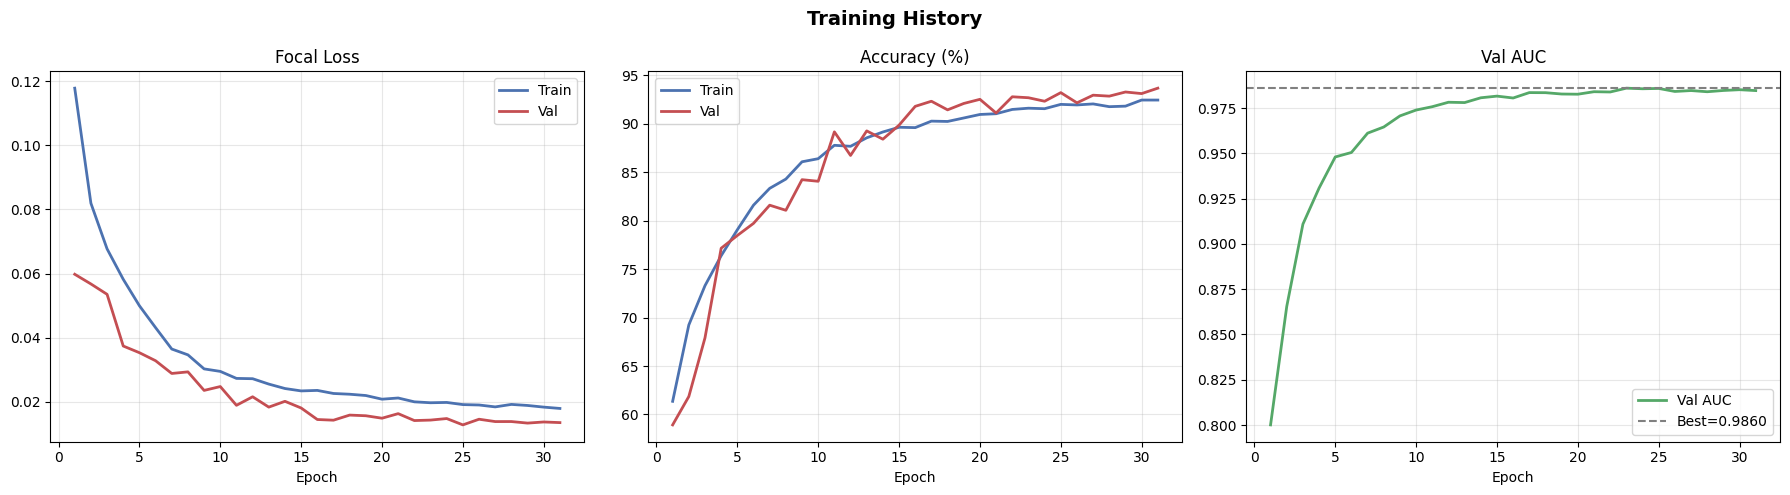

In [17]:
# Training curves
ep = range(1, len(history['train_loss']) + 1)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].plot(ep, history['train_loss'], '#4C72B0', lw=2, label='Train')
axes[0].plot(ep, history['val_loss'],   '#C44E52', lw=2, label='Val')
axes[0].set(title='Focal Loss', xlabel='Epoch'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(ep, [a*100 for a in history['train_acc']], '#4C72B0', lw=2, label='Train')
axes[1].plot(ep, [a*100 for a in history['val_acc']],   '#C44E52', lw=2, label='Val')
axes[1].set(title='Accuracy (%)', xlabel='Epoch'); axes[1].legend(); axes[1].grid(alpha=0.3)
axes[2].plot(ep, history['val_auc'], '#55A868', lw=2, label='Val AUC')
axes[2].axhline(best_auc, color='gray', ls='--', lw=1.5, label=f'Best={best_auc:.4f}')
axes[2].set(title='Val AUC', xlabel='Epoch'); axes[2].legend(); axes[2].grid(alpha=0.3)
plt.suptitle('Training History', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(CFG.OUTPUT_DIR / 'training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8. Test Set Evaluation

In [18]:
ckpt = torch.load(CFG.MODEL_PATH, map_location=DEVICE)
model.load_state_dict(ckpt['model_state_dict'])
print(f"Loaded checkpoint — epoch={ckpt['epoch']}  val AUC={ckpt['best_auc']:.4f}")

test_loss, test_acc, test_probs, test_labels = eval_epoch(model, test_loader, criterion)
print(f'\nTest Set  ({len(test_df):,} samples)')
print(f'  Loss     : {test_loss:.4f}')
print(f'  Accuracy : {test_acc*100:.2f}%  (misleading due to imbalance — AUC is primary)')

Loaded checkpoint — epoch=23  val AUC=0.9860



Test Set  (19,650 samples)
  Loss     : 0.0132
  Accuracy : 92.42%  (misleading due to imbalance — AUC is primary)


---
## 9. ROC Curve & AUC  ← Primary Metric

Test AUC          : 0.9773
Optimal threshold : 0.5242
  TPR (recall)    : 0.9538
  FPR             : 0.0669


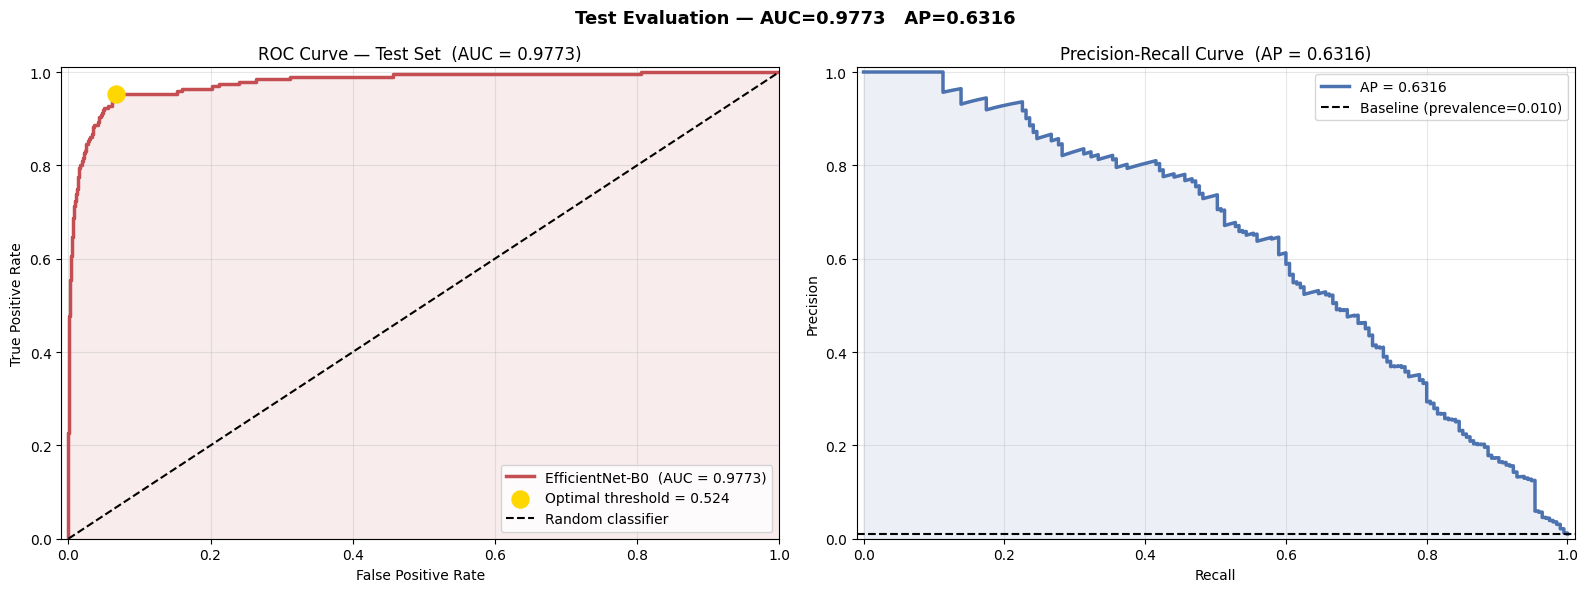

In [19]:
fpr, tpr, thresholds = roc_curve(test_labels, test_probs)
test_auc = auc(fpr, tpr)

# Optimal threshold via Youden's J = TPR - FPR
J             = tpr - fpr
opt_idx       = J.argmax()
opt_threshold = thresholds[opt_idx]
opt_tpr       = tpr[opt_idx]
opt_fpr       = fpr[opt_idx]

print(f'Test AUC          : {test_auc:.4f}')
print(f'Optimal threshold : {opt_threshold:.4f}')
print(f'  TPR (recall)    : {opt_tpr:.4f}')
print(f'  FPR             : {opt_fpr:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ROC
ax = axes[0]
ax.plot(fpr, tpr, '#C44E52', lw=2.5,
        label=f'EfficientNet-B0  (AUC = {test_auc:.4f})')
ax.scatter([opt_fpr], [opt_tpr], color='gold', s=150, zorder=5,
           label=f'Optimal threshold = {opt_threshold:.3f}')
ax.plot([0,1],[0,1], 'k--', lw=1.5, label='Random classifier')
ax.fill_between(fpr, tpr, alpha=0.10, color='#C44E52')
ax.set(xlim=[-0.01,1], ylim=[0,1.01],
       xlabel='False Positive Rate', ylabel='True Positive Rate',
       title=f'ROC Curve — Test Set  (AUC = {test_auc:.4f})')
ax.legend(loc='lower right', fontsize=10); ax.grid(alpha=0.3)

# Precision-Recall
precision, recall, _ = precision_recall_curve(test_labels, test_probs)
ap = average_precision_score(test_labels, test_probs)
ax2 = axes[1]
ax2.plot(recall, precision, '#4C72B0', lw=2.5, label=f'AP = {ap:.4f}')
ax2.axhline(test_labels.mean(), color='k', ls='--', lw=1.5,
            label=f'Baseline (prevalence={test_labels.mean():.3f})')
ax2.fill_between(recall, precision, alpha=0.10, color='#4C72B0')
ax2.set(xlim=[-0.01,1.01], ylim=[0,1.01],
        xlabel='Recall', ylabel='Precision',
        title=f'Precision-Recall Curve  (AP = {ap:.4f})')
ax2.legend(loc='upper right', fontsize=10); ax2.grid(alpha=0.3)

plt.suptitle(f'Test Evaluation — AUC={test_auc:.4f}   AP={ap:.4f}',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(CFG.OUTPUT_DIR / 'roc_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 10. Confusion Matrix

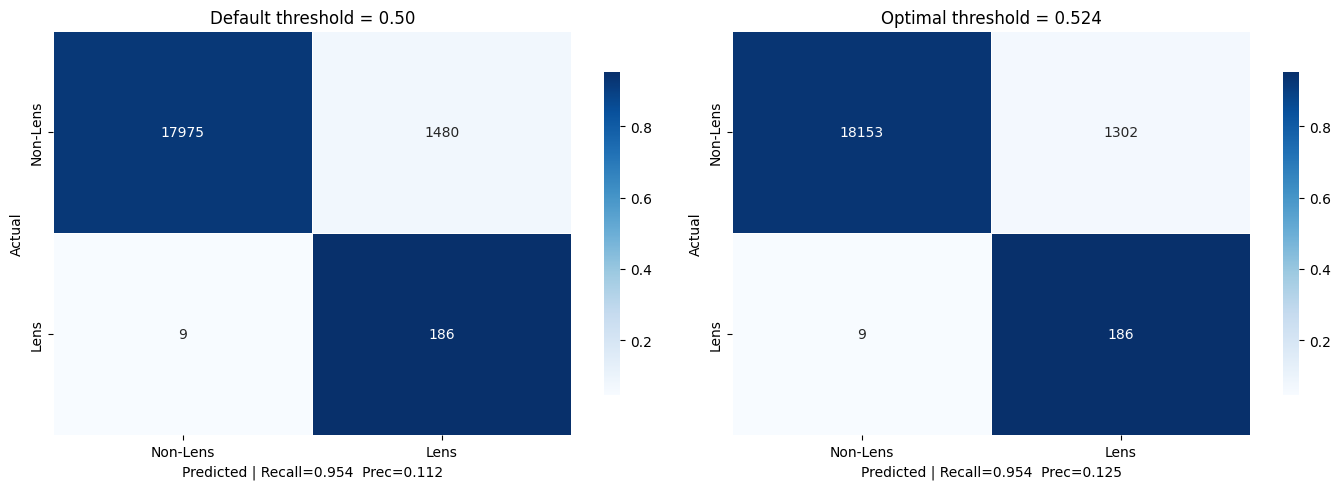

Classification Report (optimal threshold):
              precision    recall  f1-score   support

    Non-Lens     0.9995    0.9331    0.9651     19455
        Lens     0.1250    0.9538    0.2210       195

    accuracy                         0.9333     19650
   macro avg     0.5623    0.9435    0.5931     19650
weighted avg     0.9908    0.9333    0.9578     19650



In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, thresh, title in zip(
    axes,
    [0.5, opt_threshold],
    ['Default threshold = 0.50', f'Optimal threshold = {opt_threshold:.3f}']
):
    preds = (test_probs >= thresh).astype(int)
    cm    = confusion_matrix(test_labels, preds)
    cm_n  = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_n, annot=cm, fmt='d', cmap='Blues',
                xticklabels=CFG.CLASS_NAMES, yticklabels=CFG.CLASS_NAMES,
                linewidths=0.5, ax=ax, cbar_kws={'shrink':0.8})
    tp = cm[1,1]; fn = cm[1,0]; fp = cm[0,1]
    rec  = tp/(tp+fn) if (tp+fn)>0 else 0
    prec = tp/(tp+fp) if (tp+fp)>0 else 0
    ax.set(xlabel=f'Predicted | Recall={rec:.3f}  Prec={prec:.3f}',
           ylabel='Actual', title=title)

plt.tight_layout()
plt.savefig(CFG.OUTPUT_DIR / 'confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

opt_preds = (test_probs >= opt_threshold).astype(int)
print('Classification Report (optimal threshold):')
print(classification_report(test_labels, opt_preds,
                             target_names=CFG.CLASS_NAMES, digits=4))

---
## 11. Score Distribution

In [ ]:
lens_scores    = test_probs[test_labels == 1]
nonlens_scores = test_probs[test_labels == 0]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, yscale in zip(axes, ['linear', 'log']):
    ax.hist(nonlens_scores, bins=80, color='#4C72B0', alpha=0.7,
            label=f'Non-Lens (n={len(nonlens_scores):,})', density=True)
    ax.hist(lens_scores,    bins=80, color='#C44E52', alpha=0.7,
            label=f'Lens     (n={len(lens_scores):,})', density=True)
    ax.axvline(opt_threshold, color='gold', lw=2.5, ls='--',
               label=f'Optimal threshold={opt_threshold:.3f}')
    ax.set(xlabel='P(lens)', ylabel='Density',
           title=f'Score Distribution ({yscale} scale)', yscale=yscale)
    ax.legend(); ax.grid(alpha=0.3)

plt.suptitle('Predicted Score Distributions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(CFG.OUTPUT_DIR / 'score_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 12. Final Results Summary

In [ ]:
opt_preds = (test_probs >= opt_threshold).astype(int)
def_preds = (test_probs >= 0.50).astype(int)

results_df = pd.DataFrame({
    'Metric': [
        'AUC  ← primary metric',
        'Average Precision (AP)',
        'Optimal Threshold (Youden J)',
        'Recall @ optimal threshold',
        'Precision @ optimal threshold',
        'F1 @ optimal threshold',
        'Recall @ 0.5 threshold',
        'Precision @ 0.5 threshold',
        'F1 @ 0.5 threshold',
    ],
    'Score': [
        f'{test_auc:.4f}',
        f'{ap:.4f}',
        f'{opt_threshold:.4f}',
        f'{recall_score(test_labels, opt_preds):.4f}',
        f'{precision_score(test_labels, opt_preds, zero_division=0):.4f}',
        f'{f1_score(test_labels, opt_preds, zero_division=0):.4f}',
        f'{recall_score(test_labels, def_preds):.4f}',
        f'{precision_score(test_labels, def_preds, zero_division=0):.4f}',
        f'{f1_score(test_labels, def_preds, zero_division=0):.4f}',
    ]
})
results_df.to_csv(CFG.OUTPUT_DIR / 'results.csv', index=False)

print('=' * 52)
print('  FINAL RESULTS — Test Set')
print('=' * 52)
print(results_df.to_string(index=False))
print('=' * 52)
print(f'\nAll outputs → {CFG.OUTPUT_DIR}')
for f in sorted(CFG.OUTPUT_DIR.iterdir()):
    print(f'  {f.name:38s} {f.stat().st_size/1e3:7.1f} KB')

---
## Strategy Discussion

### Core Challenge: Extreme Class Imbalance
The test set has a **~100:1 non-lens to lens ratio**. Standard accuracy is meaningless — a model predicting non-lens for everything achieves 99% accuracy but zero scientific utility. Every design decision in this framework is driven by this imbalance.

### Why EfficientNet-B0 (not B3)?
Images are natively 64×64. EfficientNet-B3 expects 300px — feeding 64px images would collapse all spatial information through repeated downsampling before the network can learn lensing arc features. B0 is the lightest EfficientNet variant and handles 64px inputs most gracefully while still leveraging ImageNet transfer learning.

### Double Attack on Imbalance
1. **Focal Loss** (data-level): `FL = -α(1-p)^γ log(p)` — down-weights easy negatives via `(1-p)^γ`, forcing the model to focus on hard borderline lens candidates.
2. **WeightedRandomSampler** (batch-level): ensures every training batch contains ~50% lenses despite the 1:16 ratio in the training pool.

### Threshold Optimisation
For lens detection, missing a real lens (false negative) has high scientific cost. The default 0.5 threshold is arbitrary. **Youden's J statistic** (maximising TPR−FPR) gives the threshold that best balances sensitivity and specificity for this problem.

### Why Precision-Recall alongside ROC?
ROC curves can be misleadingly optimistic under extreme imbalance because they include true negatives in their denominator (the majority class inflates TNR). Precision-Recall curves are more informative for rare positive detection — they directly show how many predicted lenses are real (precision) and how many real lenses are found (recall).